In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"
  from IPython.display import set_matplotlib_formats
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L1VzZXJzL2t5bGV3b2RlaG91c2UvRG9jdW1lbnRzL3F1YXJ0byB3ZWJzaXRlcy9wZXJzb25hbC9wcm9qZWN0cy93ZWF0aGVyYmFpbHM='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
# globals()["__spec__"] = None

/var/folders/f9/38nkw6517lgf362dv55hy0xc0000gn/T/ipykernel_31629/1929578390.py:25: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats(fig_format)


{"/Users/kylewodehouse/anaconda3/lib/python3.11/importlib/_bootstrap.py": 1708116864.546635, "/Users/kylewodehouse/anaconda3/lib/python3.11/importlib/_bootstrap_external.py": 1708116864.5523329, "/Users/kylewodehouse/anaconda3/lib/python3.11/zipimport.py": 1708116862.5950007, "/Users/kylewodehouse/anaconda3/lib/python3.11/codecs.py": 1708116861.9593222, "/Users/kylewodehouse/anaconda3/lib/python3.11/encodings/aliases.py": 1708116863.405618, "/Users/kylewodehouse/anaconda3/lib/python3.11/encodings/__init__.py": 1708116863.4024408, "/Users/kylewodehouse/anaconda3/lib/python3.11/encodings/utf_8.py": 1708116863.8985486, "/Users/kylewodehouse/anaconda3/lib/python3.11/abc.py": 1708116861.830416, "/Users/kylewodehouse/anaconda3/lib/python3.11/io.py": 1708116862.2192643, "/Users/kylewodehouse/anaconda3/lib/python3.11/stat.py": 1708116862.4575932, "/Users/kylewodehouse/anaconda3/lib/python3.11/_collections_abc.py": 1708116861.787264, "/Users/kylewodehouse/anaconda3/lib/python3.11/genericpath.py

In [2]:
#| warning: false

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# suppress warnings
import warnings
warnings.filterwarnings('ignore')

bails = pd.read_csv('bail_data_daily_citywide.txt')
weather = pd.read_csv('daily_weather_data.csv')

In [3]:
#| warning: false
totals = bails[bails['bail_category'] == 'Total']
bails = bails[bails['bail_category'] != 'Total']

#saving the list of columns for later !!
bail_columns = bails.columns[2:]

bails = bails.merge(weather, left_on='date_value', right_on='DATE', how='left')

#getting rid of some useless columns
bails.drop(columns=['DATE', 'STATION', 'NAME'], inplace=True)
bails = bails.fillna(0)

print(bails.columns)

Index(['date_value', 'bail_category', 'Aggravated Assault',
       'Altered Firearm Serial Number', 'Arson', 'Attempted Murder',
       'Auto Theft', 'Burglary/Commercial', 'Burglary/Residential',
       'Carjacking', 'Criminal Mischief', 'Disorderly Conduct',
       'Drug Possession', 'Drug Possession in Jails', 'Drug Sales',
       'Drug Sales with a Firearm', 'DUI', 'Ethnic Intimidation',
       'Firearm Possession by a Prohibited Person',
       'Firearm Possession without a License', 'Fraud', 'Homicide: Other',
       'Homicide: Shooting', 'Illegal Dumping/Littering', 'Non-Fatal Shooting',
       'Other Assaults', 'Other Firearm Offenses', 'Other Property Crimes',
       'Other Violent Crimes', 'Patronizing Prostitutes/Sex Workers',
       'Promoting Prostitution', 'Prostitution/Sex Work', 'Rape',
       'Retail Theft', 'Robbery', 'Robbery with a Deadly Weapon',
       'Sexual Assault and Other Sex Offenses', 'Simple Assault',
       'Strangulation', 'Theft', 'Theft from Auto', 'T

In [4]:
#| warning: false
bails[['AWND', 'PGTM', 'PRCP', 'PSUN', 'SNOW',
       'SNWD', 'TAVG', 'TMAX', 'TMIN', 'TSUN', 'WDF2', 'WDF5', 'WSF2', 'WSF5',
       'WT01', 'WT02', 'WT03', 'WT04', 'WT05', 'WT06', 'WT08', 'WT09']].describe()

,AWND,PGTM,PRCP,PSUN,SNOW,SNWD,TAVG,TMAX,TMIN,TSUN,...,WSF2,WSF5,WT01,WT02,WT03,WT04,WT05,WT06,WT08,WT09
count,24256.000000,24256.000000,24256.000000,24256.0,24256.000000,24256.000000,24256.000000,24256.000000,24256.000000,24256.0,...,24256.000000,24256.000000,24256.000000,24256.000000,24256.000000,24256.000000,24256.000000,24256.000000,24256.000000,24256.000000
mean,9.039241,0.201847,0.127503,0.0,0.069360,0.151880,54.852243,65.370712,48.519789,0.0,...,19.786972,26.166260,0.344987,0.026715,0.080805,0.013852,0.000989,0.009894,0.094327,0.002309
std,3.706535,11.112817,0.359605,0.0,0.636483,0.968468,21.252877,18.588487,17.187521,0.0,...,6.645629,8.328464,0.475374,0.161253,0.272541,0.116880,0.031441,0.098980,0.292289,0.047994
min,0.670000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,13.000000,2.000000,0.0,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.490000,0.000000,0.000000,0.0,0.000000,0.000000,42.000000,50.000000,34.000000,0.0,...,15.000000,19.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,8.500000,0.000000,0.000000,0.0,0.000000,0.000000,58.000000,67.000000,48.000000,0.0,...,18.100000,25.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,10.960000,0.000000,0.060000,0.0,0.000000,0.000000,73.000000,82.000000,64.000000,0.0,...,23.000000,30.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,26.620000,612.000000,4.760000,0.0,19.400000,18.100000,90.000000,98.000000,82.000000,0.0,...,55.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
#| warning: false

X = bails.loc[(bails['bail_category'] == '$25k-$100k') & (bails['Drug Sales'] > 0)][['AWND', 'PGTM', 'PRCP', 'PSUN', 'SNOW',
       'SNWD', 'TAVG', 'TMAX', 'TMIN', 'TSUN', 'WDF2', 'WDF5', 'WSF2', 'WSF5',
       'WT01', 'WT02', 'WT03', 'WT04', 'WT05', 'WT06', 'WT08', 'WT09']]
y = bails.loc[(bails['bail_category'] == '$25k-$100k') & (bails['Drug Sales'] > 0)]['Drug Sales'] > 1

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,shuffle=True,random_state=4202024)

In [6]:
#| warning: false
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier

grid = { "max_depth":[6,8,10,12,14], 
         "min_samples_leaf":[1,2,3,4,7]}
learner = DecisionTreeClassifier(random_state=420)
kf = StratifiedKFold(n_splits=8, shuffle=True, random_state=2024)

grid_search = GridSearchCV(
    learner, grid, 
    scoring="recall", 
    cv=kf,
    n_jobs=-1
    )
grid_search.fit(X_train, y_train)

tree_best_params = grid_search.best_params_
tree_best_score = grid_search.best_score_
print(tree_best_params)
print(tree_best_score)

{'max_depth': 8, 'min_samples_leaf': 3}
0.6368873742291463


In [7]:
#| warning: false
from sklearn.neighbors import KNeighborsClassifier


grid = {
    'n_neighbors': range(1, 21, 2),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'leaf_size': list(range(1,50)),
}
learner = KNeighborsClassifier()
kf = StratifiedKFold(n_splits=8, shuffle=True, random_state=302)

grid_search = GridSearchCV(
    learner, grid, 
    scoring="recall", 
    cv=kf,
    n_jobs=-1
    );
grid_search.fit(X_train, y_train);

kNN_best_params = grid_search.best_params_
kNN_best_score = grid_search.best_score_
print(kNN_best_params)
print(kNN_best_score)

{'leaf_size': 1, 'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
0.5464135021097046


In [8]:
#| warning: false
best_tree = DecisionTreeClassifier(**tree_best_params)
best_tree.fit(X_train, y_train)

feature_importances = best_tree.feature_importances_
columns = X_train.columns
feature_importances = pd.Series(feature_importances, index=columns)
feature_importances = feature_importances.sort_values(ascending=True)
print(feature_importances)

WT09    0.000000
TSUN    0.000000
WT03    0.000000
WT06    0.000000
WT05    0.000000
PSUN    0.000000
PGTM    0.000000
SNOW    0.000000
WT04    0.000000
WT02    0.011677
SNWD    0.015442
WT01    0.015442
WT08    0.020802
PRCP    0.027830
WDF5    0.058717
WSF2    0.060131
TMAX    0.082825
WSF5    0.094766
WDF2    0.125744
TAVG    0.135288
TMIN    0.161345
AWND    0.189990
dtype: float64


In [9]:
#| warning: false
from sklearn.discriminant_analysis import StandardScaler
from sklearn.ensemble import BaggingClassifier
from sklearn.pipeline import make_pipeline

knn = KNeighborsClassifier(**kNN_best_params)
pipe = make_pipeline(StandardScaler(), knn)
bag = BaggingClassifier(pipe, n_estimators=50, max_samples=0.15, oob_score=True, random_state=302)
bag.fit(X_train, y_train)

from sklearn.metrics import classification_report
y_pred = bag.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.42      0.46      0.44       127
        True       0.60      0.55      0.58       182

    accuracy                           0.52       309
   macro avg       0.51      0.51      0.51       309
weighted avg       0.53      0.52      0.52       309



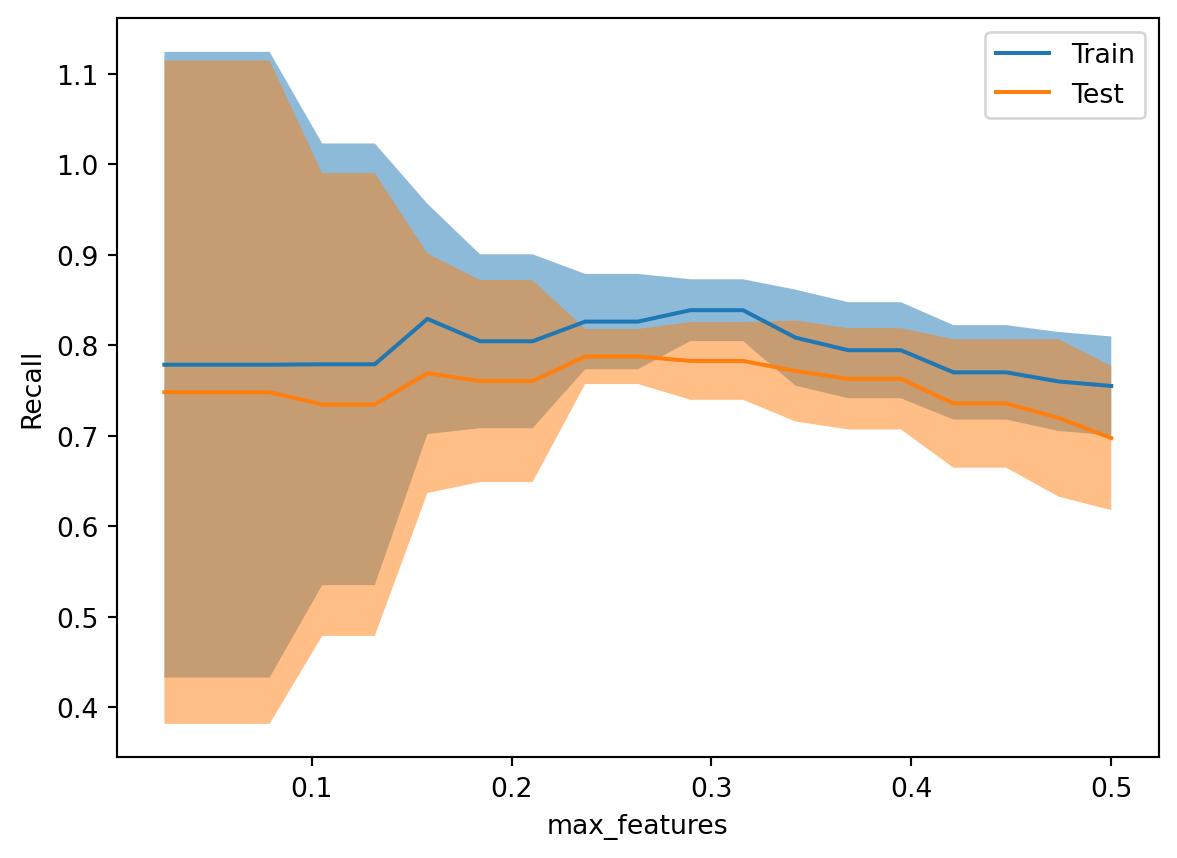

In [10]:
#| warning: false
from sklearn.model_selection import ValidationCurveDisplay

ValidationCurveDisplay.from_estimator(
    bag, X, y,
    param_name="max_features", 
    param_range=np.linspace(0, 0.5, 20),
    cv=StratifiedKFold(n_splits=6, shuffle=True, random_state=19716),
    scoring="recall",
    n_jobs=-1
    )

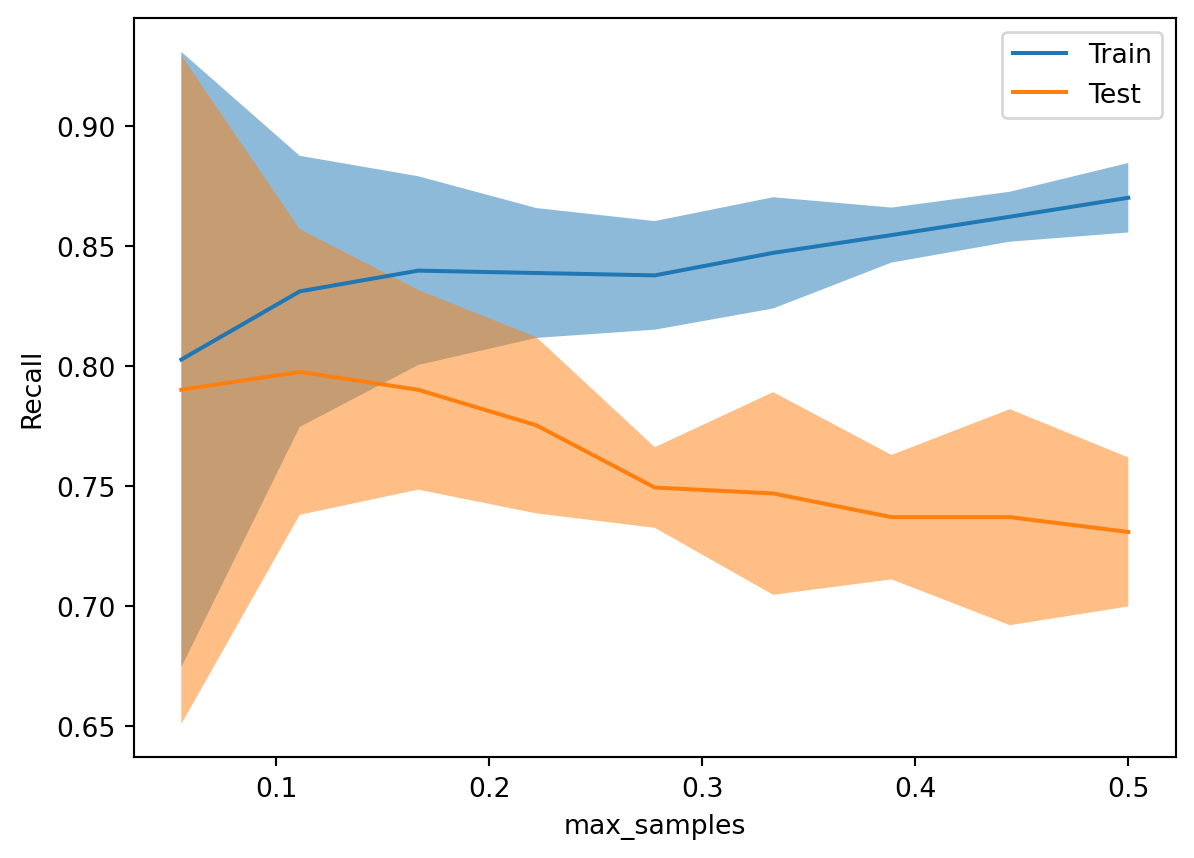

In [11]:
#| warning: false
bag = BaggingClassifier(pipe, n_estimators=50, max_samples=0.15,max_features=0.3, oob_score=True, random_state=302)
bag.fit(X_train, y_train)

ValidationCurveDisplay.from_estimator(
    bag, X, y,
    param_name="max_samples", 
    param_range=np.linspace(0, 0.5, 10),
    cv=StratifiedKFold(n_splits=6, shuffle=True, random_state=19716),
    scoring="recall",
    n_jobs=-1
    )

In [12]:
#| warning: false
bag = BaggingClassifier(pipe, n_estimators=50, max_samples=0.1,max_features=0.3, oob_score=True, random_state=302)
bag.fit(X_train, y_train)

print(classification_report(y_test, best_tree.predict(X_test)))
print(classification_report(y_train, bag.predict(X_train)))

              precision    recall  f1-score   support

       False       0.41      0.34      0.37       127
        True       0.59      0.66      0.63       182

    accuracy                           0.53       309
   macro avg       0.50      0.50      0.50       309
weighted avg       0.52      0.53      0.52       309



              precision    recall  f1-score   support

       False       0.57      0.41      0.48       606
        True       0.55      0.71      0.62       628

    accuracy                           0.56      1234
   macro avg       0.56      0.56      0.55      1234
weighted avg       0.56      0.56      0.55      1234



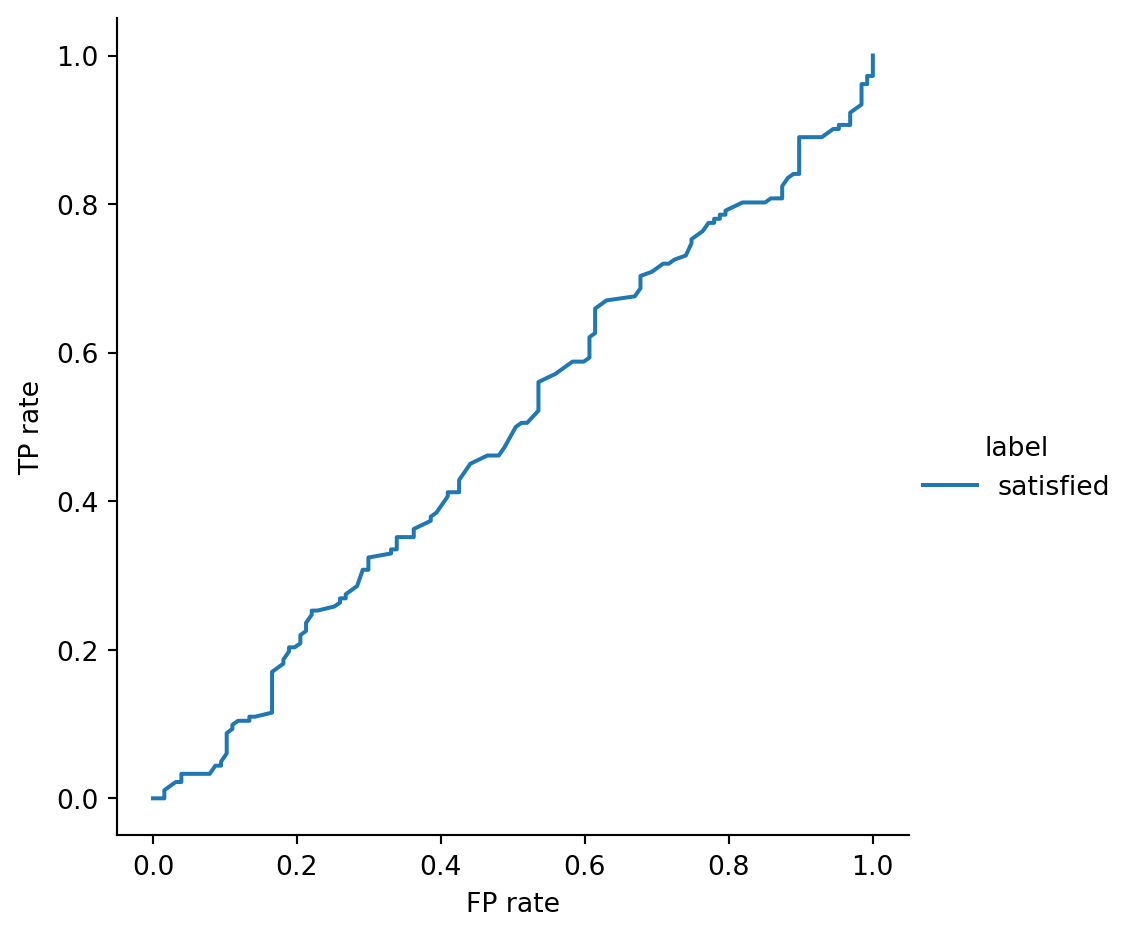

In [13]:
#| warning: false
from sklearn.metrics import roc_curve

results = []
actual = y_test
p_hat = bag.predict_proba(X_test)
fp, tp, theta = roc_curve(actual,p_hat[:,1])
results.extend( [('satisfied',fp,tp) for fp,tp in zip(fp,tp)] )
roc = pd.DataFrame( results, columns=["label","FP rate","TP rate"] )
sns.relplot(data=roc, 
    x="FP rate", y="TP rate", 
    hue="label", kind="line", estimator=None
    )

In [14]:
#| warning: false
print(totals)

totals['sum_bails'] = totals[bail_columns].sum(axis=1)

totals = totals.merge(weather, left_on='date_value', right_on='DATE', how='left')

       date_value bail_category  Aggravated Assault   
0      2014-01-01         Total                  18  \
9      2014-01-02         Total                  38   
18     2014-01-03         Total                  13   
27     2014-01-04         Total                  12   
36     2014-01-05         Total                   5   
...           ...           ...                 ...   
27243  2022-04-16         Total                  10   
27252  2022-04-17         Total                   6   
27261  2022-04-18         Total                   9   
27270  2022-04-19         Total                  10   
27279  2022-04-20         Total                   4   

       Altered Firearm Serial Number  Arson  Attempted Murder  Auto Theft   
0                                  0      0                 2           4  \
9                                  1      0                 4           3   
18                                 0      0                 0           2   
27                             

In [15]:
#| warning: false

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge

X = totals[['AWND', 'PGTM', 'PRCP',
       'PSUN', 'SNOW', 'SNWD', 'TAVG', 'TMAX', 'TMIN', 'TSUN', 'WDF2', 'WDF5',
       'WSF2', 'WSF5', 'WT01', 'WT02', 'WT03', 'WT04', 'WT05', 'WT06', 'WT08',
       'WT09']].fillna(0)
y = totals['Carjacking'] / totals['sum_bails']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,shuffle=True,random_state=4202024)


rr = Ridge(alpha=0.5)
pipe = make_pipeline(StandardScaler(), rr)
pipe.fit(X_train, y_train)
print(f"ridge CoD score: {pipe.score(X_test, y_test):.4f}")

ridge CoD score: 0.0064


best alpha: 404.0404
best score: 0.0101


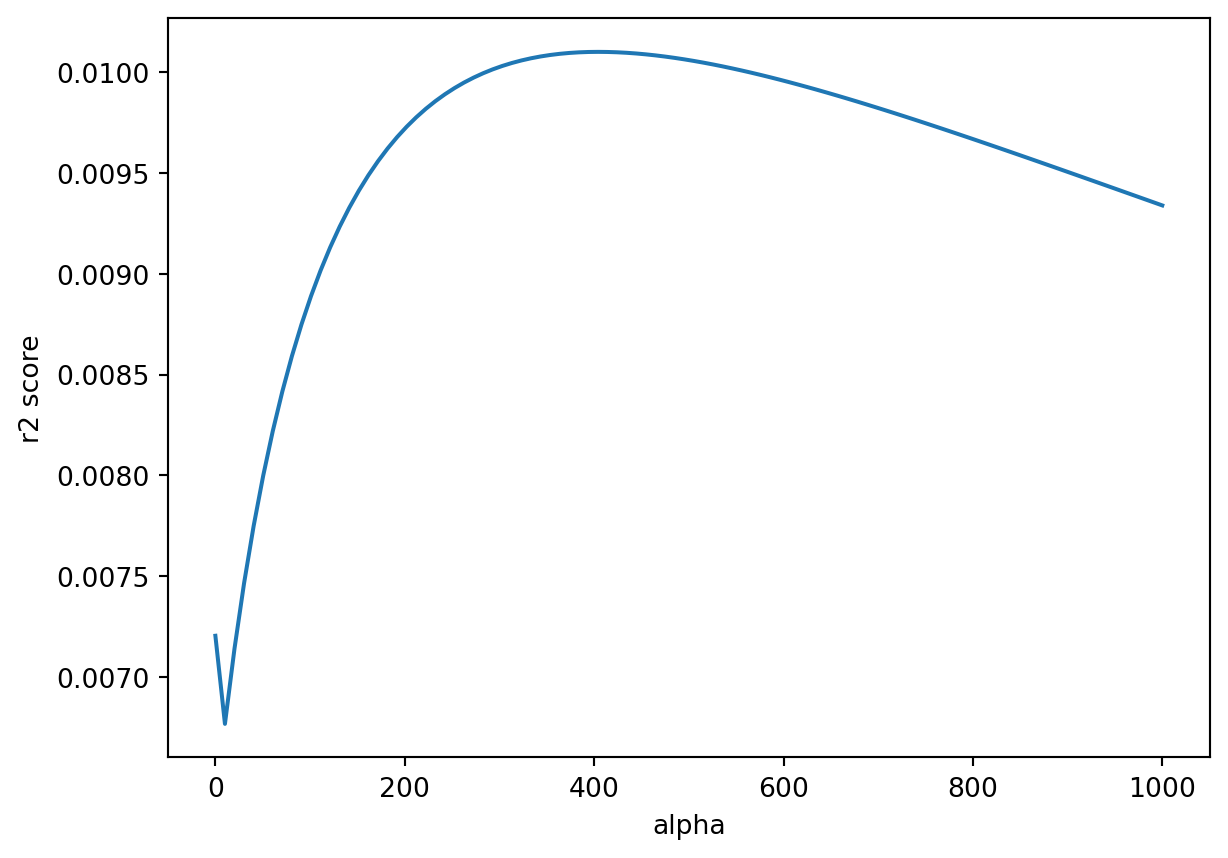

In [16]:
#| warning: false
def test_alpha(alphaa):
    rr = Ridge(alpha=alphaa)
    pipe = make_pipeline(StandardScaler(), rr)
    pipe.fit(X_train, y_train)
    return pipe.score(X_test, y_test)

alphas = np.linspace(0, 1000, 100)
scores = [test_alpha(alpha) for alpha in alphas]
plt.plot(alphas, scores)
plt.xlabel("alpha")
plt.ylabel("r2 score")

best_alpha = alphas[np.argmax(scores)]
print(f"best alpha: {best_alpha:.4f}")
best_score = np.max(scores)
print(f"best score: {best_score:.4f}")

In [17]:
#| warning: false
rr = Ridge(alpha=best_alpha)
pipe = make_pipeline(StandardScaler(), rr)
pipe.fit(X_train, y_train)

weights_ridge = pd.Series(pipe.named_steps['ridge'].coef_, index=X_test.columns)
weights_ridge = weights_ridge.sort_values(ascending=True)
print(weights_ridge)

WT04   -0.000299
TMIN   -0.000293
WDF5   -0.000225
TMAX   -0.000204
SNOW   -0.000188
WT09   -0.000138
WSF2   -0.000136
WT03   -0.000123
PGTM   -0.000096
WT05   -0.000053
SNWD   -0.000048
WT01   -0.000014
PSUN    0.000000
TSUN    0.000000
WSF5    0.000008
WT02    0.000025
WT08    0.000028
PRCP    0.000136
AWND    0.000311
WT06    0.000337
WDF2    0.000546
TAVG    0.000565
dtype: float64


In [18]:
#| warning: false
from sklearn.linear_model import Lasso
lass = Lasso(alpha=0.5)
lass.fit(X_train, y_train)
weights_lass = pd.Series(lass.coef_, index=X_train.columns)
print(weights_lass)
dropped = weights_lass[weights_lass == 0].index
print('dropped cols:' + '\n', dropped)

AWND    0.0
PGTM   -0.0
PRCP    0.0
PSUN    0.0
SNOW   -0.0
SNWD   -0.0
TAVG    0.0
TMAX   -0.0
TMIN   -0.0
TSUN    0.0
WDF2    0.0
WDF5    0.0
WSF2    0.0
WSF5    0.0
WT01   -0.0
WT02    0.0
WT03   -0.0
WT04   -0.0
WT05   -0.0
WT06    0.0
WT08   -0.0
WT09   -0.0
dtype: float64
dropped cols:
 Index(['AWND', 'PGTM', 'PRCP', 'PSUN', 'SNOW', 'SNWD', 'TAVG', 'TMAX', 'TMIN',
       'TSUN', 'WDF2', 'WDF5', 'WSF2', 'WSF5', 'WT01', 'WT02', 'WT03', 'WT04',
       'WT05', 'WT06', 'WT08', 'WT09'],
      dtype='object')


Text(0, 0.5, 'sum abs(coeff_)')

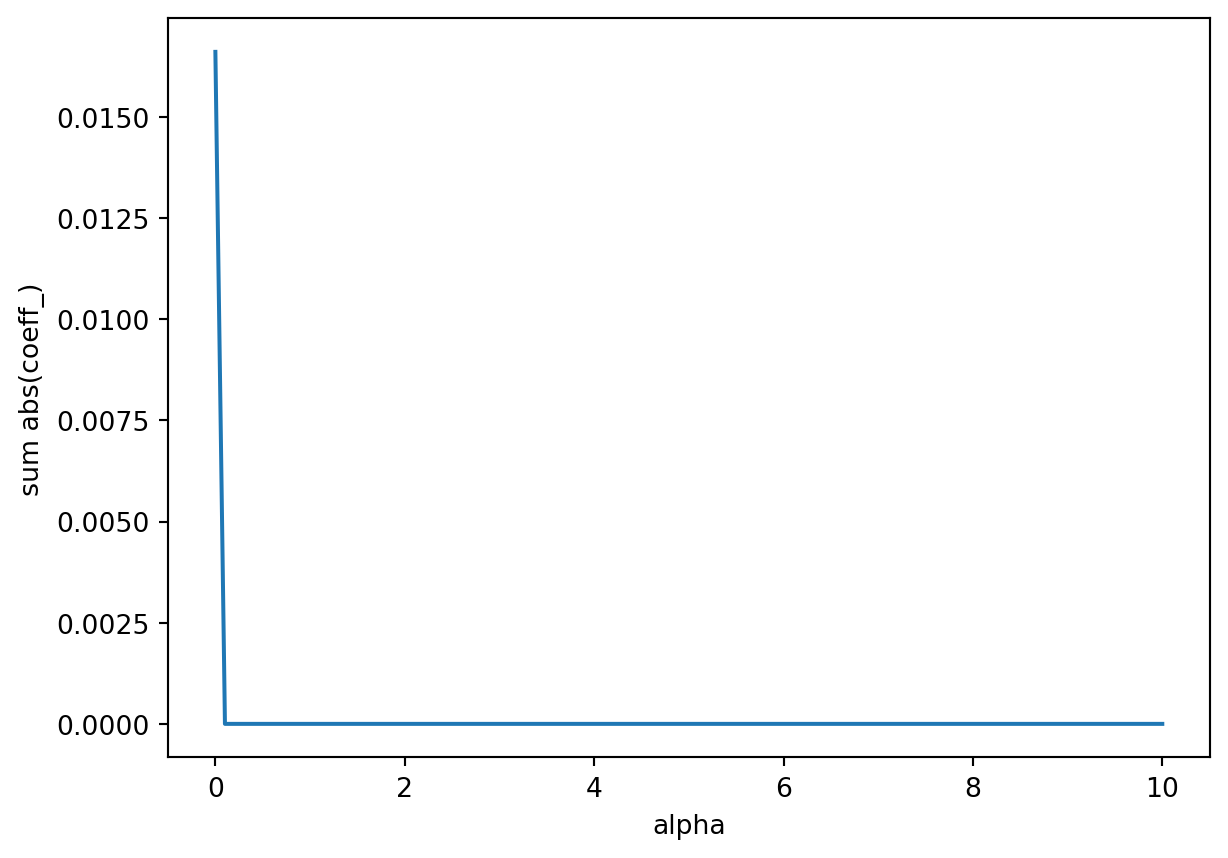

In [19]:
#| warning: false
def test_alpha(alphaa):
    lass = Lasso(alpha=alphaa)
    lass.fit(X_train, y_train)
    return abs(lass.coef_).sum()

alphas = np.linspace(0, 10, 100)
scores = [test_alpha(alpha) for alpha in alphas]
plt.plot(alphas, scores)
plt.xlabel("alpha")
plt.ylabel("sum abs(coeff_)")

Text(0, 0.5, 'sum abs(coeff_)')

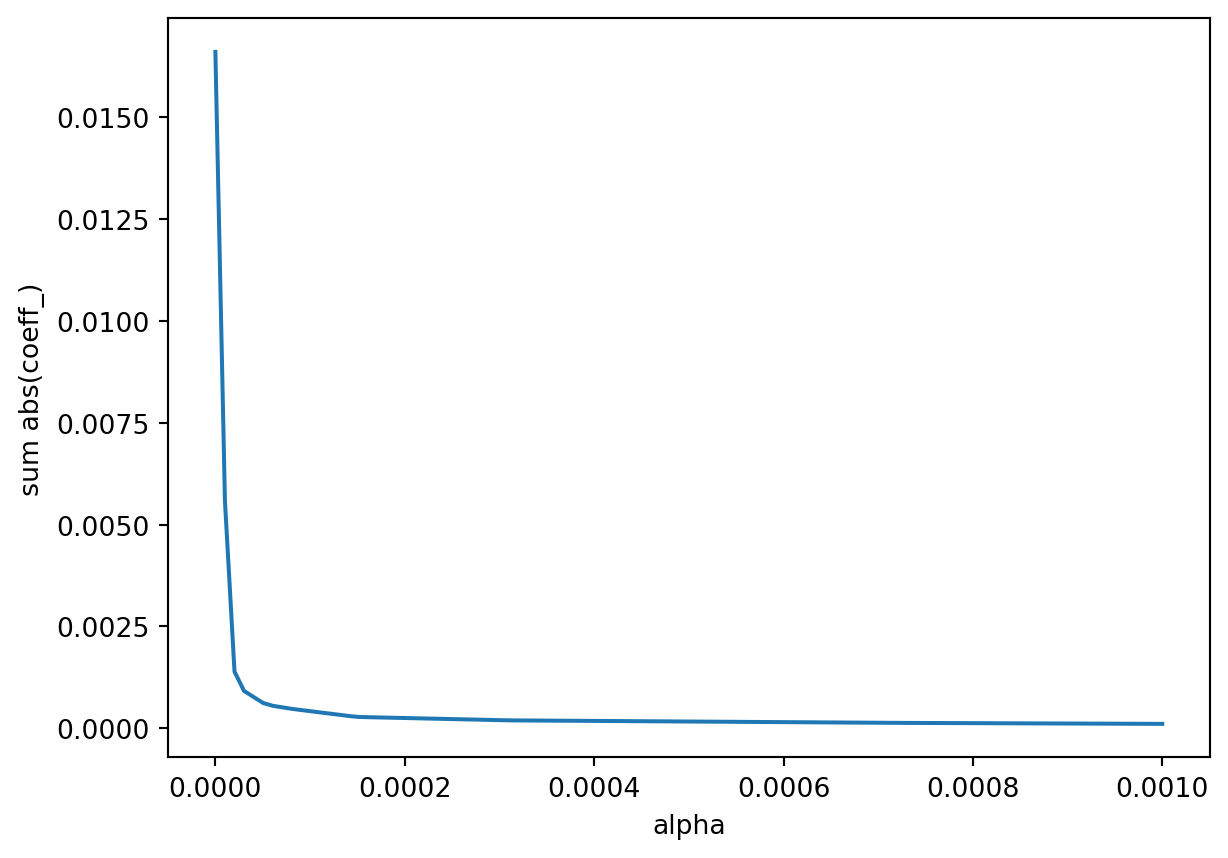

In [20]:
#| warning: false
alphas = np.linspace(0, 0.001, 100)
scores = [test_alpha(alpha) for alpha in alphas]
plt.plot(alphas, scores)
plt.xlabel("alpha")
plt.ylabel("sum abs(coeff_)")

In [21]:
#| warning: false
from sklearn.tree import DecisionTreeRegressor

grid = { "max_depth":[2,6,8,10,12,14], 
         "min_samples_leaf":[2,3,4,7]}
learner = DecisionTreeRegressor(random_state=420)

grid_search = GridSearchCV(
    learner, grid, 
    scoring="r2", 
    n_jobs=-1
    )
grid_search.fit(X_train, y_train)

tree_best_params = grid_search.best_params_
tree_best_score = grid_search.best_score_
print(tree_best_params)

treez = DecisionTreeRegressor(**tree_best_params)
treez.fit(X_train, y_train)
CofD_dtr = treez.score(X_test, y_test)
print(f"Decision Tree Regressor r2 score: {CofD_dtr:.4f}")
top_feature = X_train.columns[np.argmax(treez.feature_importances_)]
print(f"Most important feature: {top_feature}")

{'max_depth': 2, 'min_samples_leaf': 2}
Decision Tree Regressor r2 score: -0.0018
Most important feature: TAVG


best alpha: 404.0404
best score: 0.0101


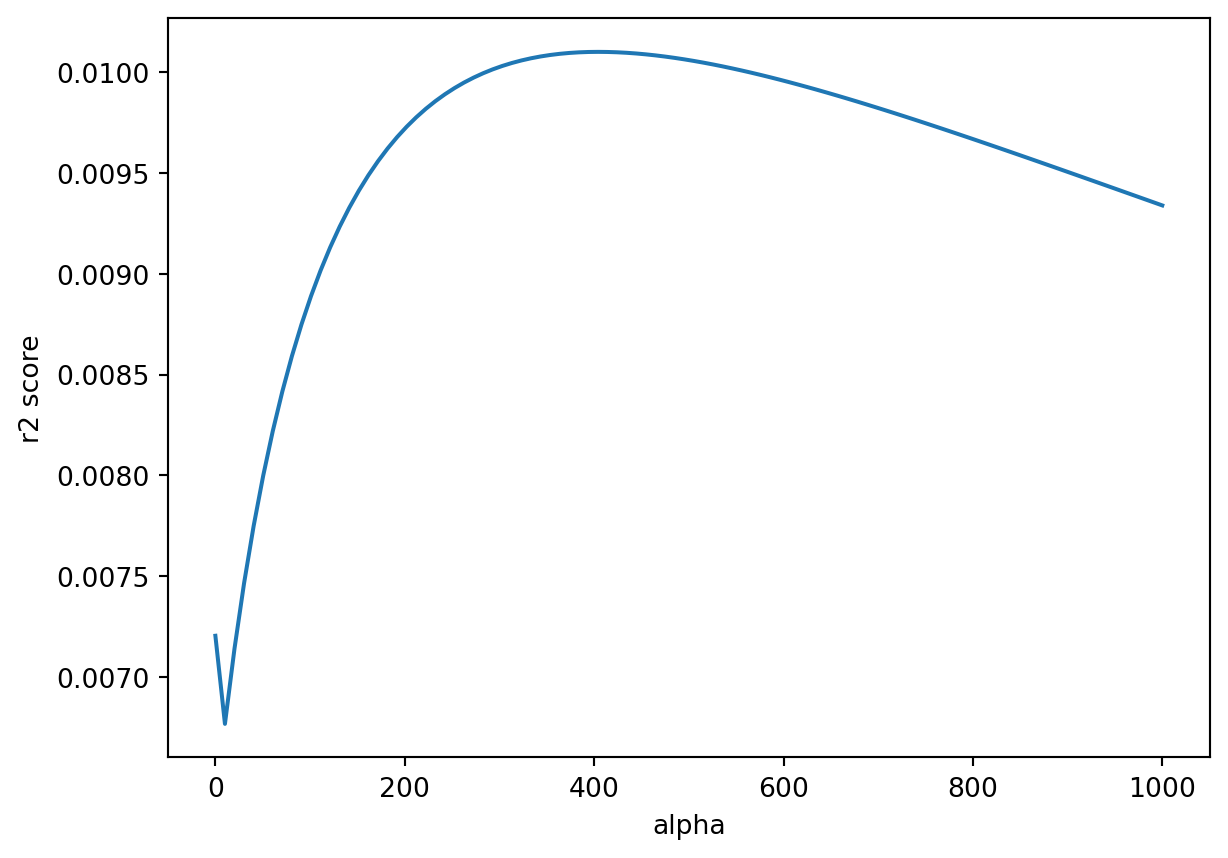

In [22]:
#| warning: false
addnl_columns = []
for column in totals.columns:
    if type(totals[column][0]) == float:
        totals[f"log_{column}"] = np.log(totals[column])
        totals[f"sqrt_{column}"] = np.sqrt(totals[column])
        totals[f"exp_{column}"] = np.exp(totals[column])
        totals[f"inv_{column}"] = 1 / totals[column]
        addnl_columns.append(f"log_{column}")
        addnl_columns.append(f"sqrt_{column}")
        addnl_columns.append(f"exp_{column}")
        addnl_columns.append(f"inv_{column}")
totals['prod_tavgmax'] = totals['TAVG'] * totals['TMAX']


X = totals[['AWND', 'PGTM', 'PRCP',
       'PSUN', 'SNOW', 'SNWD', 'TAVG', 'TMAX', 'TMIN', 'TSUN', 'WDF2', 'WDF5',
       'WSF2', 'WSF5', 'WT01', 'WT02', 'WT03', 'WT04', 'WT05', 'WT06', 'WT08',
       'WT09'] + addnl_columns].fillna(0)
y = totals['Carjacking'] / totals['sum_bails']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,shuffle=True,random_state=4202024)

def test_alpha(alphaa):
    rr = Ridge(alpha=alphaa)
    pipe = make_pipeline(StandardScaler(), rr)
    pipe.fit(X_train, y_train)
    return pipe.score(X_test, y_test)

alphas = np.linspace(0, 1000, 100)
scores = [test_alpha(alpha) for alpha in alphas]
plt.plot(alphas, scores)
plt.xlabel("alpha")
plt.ylabel("r2 score")

best_alpha = alphas[np.argmax(scores)]
print(f"best alpha: {best_alpha:.4f}")
best_score = np.max(scores)
print(f"best score: {best_score:.4f}")